In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")


# STEP 1 - load preprocessed datasets
# forward selected features dataset
df = pd.read_csv("preprocessed_data.csv")
# pca dataset
df_pca = pd.read_csv("preprocessed_data_pca.csv")

print("preprocessed_data shape:", df.shape)
print("preprocessed_data_pca shape:", df_pca.shape)

print()
print("columns in preprocessed_data:")
print(df.columns.tolist())

print()
print("first 10 rows:")
print(df.head(5))

preprocessed_data shape: (1051, 9)
preprocessed_data_pca shape: (1051, 11)

columns in preprocessed_data:
['CO2_Level_ppm', 'Appliance_Usage', 'Temperature_C', 'Occupancy_Level', 'Wind_Speed_kmh', 'Time_of_Day', 'Event_Type', 'Weather_Condition', 'Energy_Consumption_kWh']

first 10 rows:
   CO2_Level_ppm  Appliance_Usage  Temperature_C  Occupancy_Level  \
0       0.345846        -0.404780       0.229597                1   
1       0.840539         1.047644       0.093314                1   
2       0.782462        -0.707368      -0.213323                1   
3      -0.006766        -1.554616      -0.135319                4   
4      -0.763844         1.047644       0.798938                2   

   Wind_Speed_kmh  Time_of_Day  Event_Type  Weather_Condition  \
0        1.608631    -1.561673           1                  6   
1        1.707401     0.314840           4                  5   
2        1.566301    -1.272979           2                  2   
3       -0.331493    -0.406896      

In [5]:
# STEP 2 - split features and target
print(" \t splitting features and target \n ")
# for forward selected features
X = df.drop(columns=['Energy_Consumption_kWh'])
y = df['Energy_Consumption_kWh']
# for pca features
X_pca = df_pca.drop(columns=['Energy_Consumption_kWh'])
y_pca = df_pca['Energy_Consumption_kWh']
print("X shape (forward features) :", X.shape)
print("y shape :", y.shape)
print("X_pca shape :", X_pca.shape)

 	 splitting features and target 
 
X shape (forward features) : (1051, 8)
y shape : (1051,)
X_pca shape : (1051, 10)


In [6]:
# STEP 3 - train test split (80% train, 20% test)
print("train test split (80/20) ")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca, y_pca, test_size=0.2, random_state=42)

print("training set size   :", X_train.shape[0])
print("testing set size    :", X_test.shape[0])

print()
print("y_train stats:")
print(y_train.describe())

train test split (80/20) 
training set size   : 840
testing set size    : 211

y_train stats:
count     840.000000
mean      242.683739
std       147.940331
min      -145.183997
25%       183.317500
50%       233.585000
75%       286.327500
max      2749.565499
Name: Energy_Consumption_kWh, dtype: float64


In [7]:
# STEP 4 - define all regression models
print("\t defining all regression models \n")

models = {
    'Linear Regression'         : LinearRegression(),
    'Ridge Regression'          : Ridge(alpha=1.0),
    'Lasso Regression'          : Lasso(alpha=0.1),
    'Decision Tree'             : DecisionTreeRegressor(random_state=42),
    'Random Forest'             : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'         : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN Regressor'             : KNeighborsRegressor(n_neighbors=5),
    'SVR'                       : SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
}

print("models defined:")
for name in models:
    print(" -", name)

	 defining all regression models 

models defined:
 - Linear Regression
 - Ridge Regression
 - Lasso Regression
 - Decision Tree
 - Random Forest
 - Gradient Boosting
 - KNN Regressor
 - SVR


In [12]:
# STEP 5 - train and evaluate all models (forward features)
print(" training and evaluating all models on forward selected features \n ")

results = []

for name, model in models.items():
    # train
    model.fit(X_train, y_train)

    # predict on test set
    y_pred = model.predict(X_test)

    # calculate metrics
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    # cross validation r2 (5 fold)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_mean   = cv_scores.mean()
    cv_std    = cv_scores.std()

    results.append({
        'Model'        : name,
        'MAE'          : round(mae, 4),
        'MSE'          : round(mse, 4),
        'RMSE'         : round(rmse, 4),
        'R2 Score'     : round(r2, 4),
        'CV R2 Mean'   : round(cv_mean, 4),
        'CV R2 Std'    : round(cv_std, 4)
    })

    print(f"Model     : {name}")
    print(f"  MAE     : {mae:.4f}")
    print(f"  MSE     : {mse:.4f}")
    print(f"  RMSE    : {rmse:.4f}")
    print(f"  R2      : {r2:.4f}")
    print(f"  CV R2   : {cv_mean:.4f} (+/- {cv_std:.4f})")
    print()

# convert to dataframe for easy comparison
results_df = pd.DataFrame(results)
print("\t\t\t model comparison table \n")
print(results_df.to_string(index=False))

 training and evaluating all models on forward selected features 
 
Model     : Linear Regression
  MAE     : 34.7509
  MSE     : 5029.5788
  RMSE    : 70.9195
  R2      : 0.3152
  CV R2   : 0.3620 (+/- 0.2382)

Model     : Ridge Regression
  MAE     : 34.7358
  MSE     : 5027.6288
  RMSE    : 70.9058
  R2      : 0.3154
  CV R2   : 0.3621 (+/- 0.2383)

Model     : Lasso Regression
  MAE     : 34.6628
  MSE     : 5017.9924
  RMSE    : 70.8378
  R2      : 0.3167
  CV R2   : 0.3622 (+/- 0.2384)

Model     : Decision Tree
  MAE     : 47.5949
  MSE     : 14119.0175
  RMSE    : 118.8235
  R2      : -0.9225
  CV R2   : -1.6510 (+/- 1.8519)

Model     : Random Forest
  MAE     : 38.5511
  MSE     : 7036.3474
  RMSE    : 83.8829
  R2      : 0.0419
  CV R2   : 0.1393 (+/- 0.1573)

Model     : Gradient Boosting
  MAE     : 43.2030
  MSE     : 9037.8530
  RMSE    : 95.0676
  R2      : -0.2306
  CV R2   : -0.0841 (+/- 0.4211)

Model     : KNN Regressor
  MAE     : 42.5740
  MSE     : 7046.2297
  RM

In [15]:
# STEP 6 - train and evaluate all models (PCA features)
print("\t Training and evaluating all models on PCA features \n")


results_pca = []

for name, model in models.items():
    model.fit(X_pca_train, y_pca_train)
    y_pred_pca = model.predict(X_pca_test)

    mae  = mean_absolute_error(y_pca_test, y_pred_pca)
    mse  = mean_squared_error(y_pca_test, y_pred_pca)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_pca_test, y_pred_pca)

    cv_scores = cross_val_score(model, X_pca, y_pca, cv=5, scoring='r2')
    cv_mean   = cv_scores.mean()
    cv_std    = cv_scores.std()

    results_pca.append({
        'Model'        : name,
        'MAE'          : round(mae, 4),
        'MSE'          : round(mse, 4),
        'RMSE'         : round(rmse, 4),
        'R2 Score'     : round(r2, 4),
        'CV R2 Mean'   : round(cv_mean, 4),
        'CV R2 Std'    : round(cv_std, 4)
    })

    print(f"Model     : {name}")
    print(f"  MAE     : {mae:.4f}")
    print(f"  MSE     : {mse:.4f}")
    print(f"  RMSE    : {rmse:.4f}")
    print(f"  R2      : {r2:.4f}")
    print(f"  CV R2   : {cv_mean:.4f} (+/- {cv_std:.4f})")
    print()

results_pca_df = pd.DataFrame(results_pca)
print("\t\t\t PCA model comparison table \n")
print(results_pca_df.to_string(index=False))

	 Training and evaluating all models on PCA features 

Model     : Linear Regression
  MAE     : 50.3534
  MSE     : 7460.5923
  RMSE    : 86.3747
  R2      : -0.0159
  CV R2   : 0.1797 (+/- 0.1456)

Model     : Ridge Regression
  MAE     : 50.3427
  MSE     : 7458.1651
  RMSE    : 86.3607
  R2      : -0.0155
  CV R2   : 0.1798 (+/- 0.1456)

Model     : Lasso Regression
  MAE     : 50.2920
  MSE     : 7447.5783
  RMSE    : 86.2994
  R2      : -0.0141
  CV R2   : 0.1799 (+/- 0.1456)

Model     : Decision Tree
  MAE     : 79.5525
  MSE     : 29504.6113
  RMSE    : 171.7691
  R2      : -3.0174
  CV R2   : -1.8839 (+/- 1.7935)

Model     : Random Forest
  MAE     : 51.3616
  MSE     : 8713.0377
  RMSE    : 93.3437
  R2      : -0.1864
  CV R2   : -0.2295 (+/- 0.2595)

Model     : Gradient Boosting
  MAE     : 53.4765
  MSE     : 12775.7841
  RMSE    : 113.0300
  R2      : -0.7396
  CV R2   : -0.3845 (+/- 0.3880)

Model     : KNN Regressor
  MAE     : 63.8193
  MSE     : 10763.3069
  RMSE   

In [16]:
# STEP 7 - identify best model
print(" identifying best model \n")
best_row     = results_df.loc[results_df['R2 Score'].idxmax()]
best_row_pca = results_pca_df.loc[results_pca_df['R2 Score'].idxmax()]
print(f"best model (forward features) : {best_row['Model']}  with R2 = {best_row['R2 Score']}")
print(f"best model (PCA features)     : {best_row_pca['Model']}  with R2 = {best_row_pca['R2 Score']}")

 identifying best model 

best model (forward features) : SVR  with R2 = 0.3706
best model (PCA features)     : SVR  with R2 = 0.1083


plotting R2 score comparison 



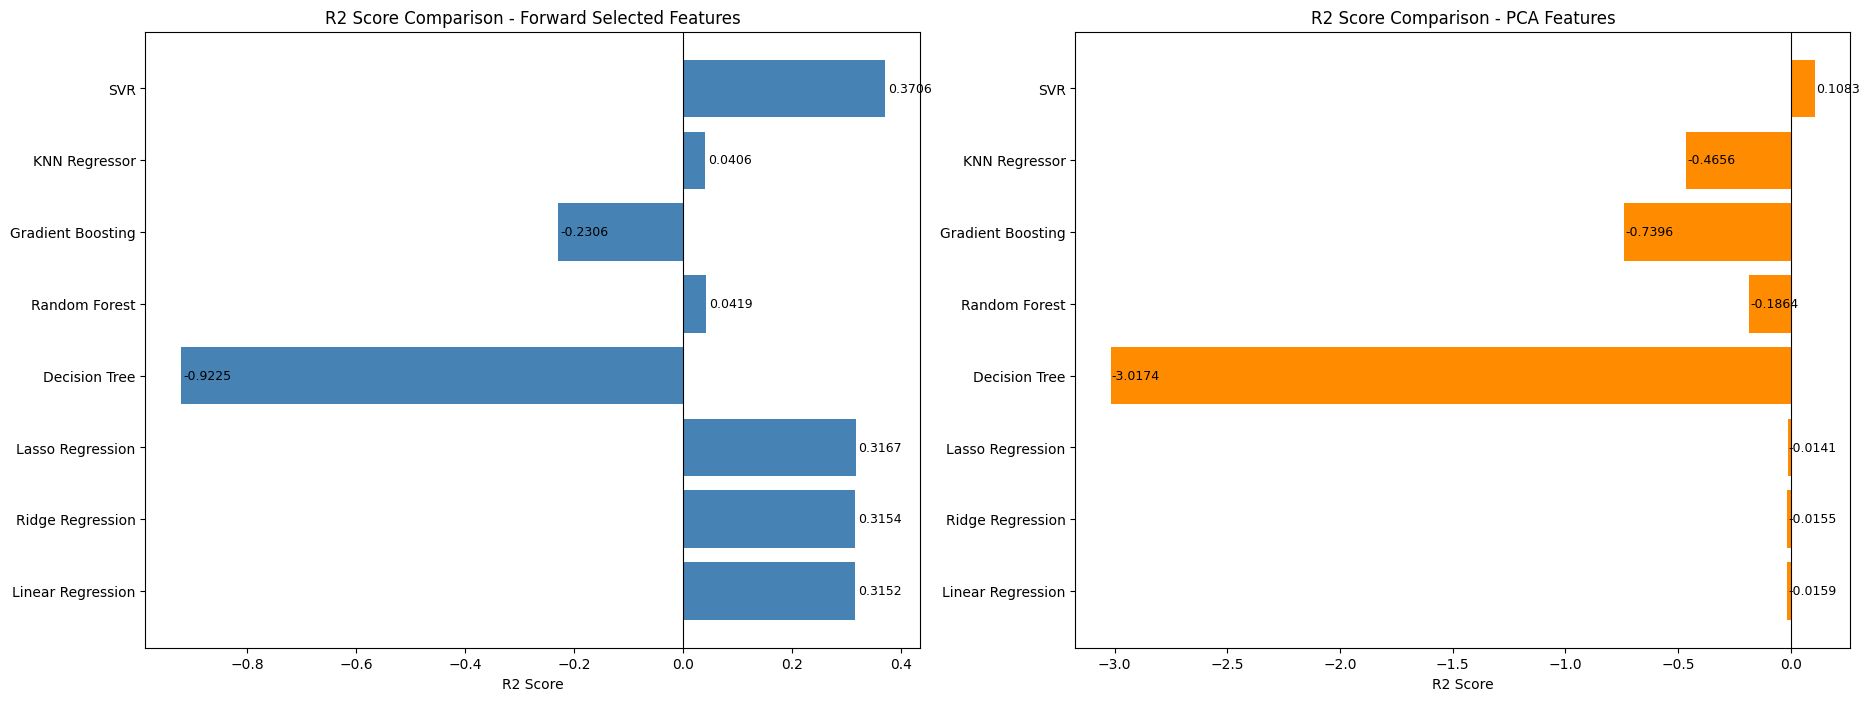

In [23]:
# STEP 8 - plot R2 score comparison (bar chart)
print("plotting R2 score comparison \n")

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# forward features
axes[0].barh(results_df['Model'], results_df['R2 Score'], color='steelblue')
axes[0].set_xlabel("R2 Score")
axes[0].set_title("R2 Score Comparison - Forward Selected Features")
axes[0].axvline(x=0, color='black', linewidth=0.8)
for i, v in enumerate(results_df['R2 Score']):
    axes[0].text(v + 0.005, i, str(v), va='center', fontsize=9)

# pca features
axes[1].barh(results_pca_df['Model'], results_pca_df['R2 Score'], color='darkorange')
axes[1].set_xlabel("R2 Score")
axes[1].set_title("R2 Score Comparison - PCA Features")
axes[1].axvline(x=0, color='black', linewidth=0.8)
for i, v in enumerate(results_pca_df['R2 Score']):
    axes[1].text(v + 0.005, i, str(v), va='center', fontsize=9)

 plotting RMSE comparison 



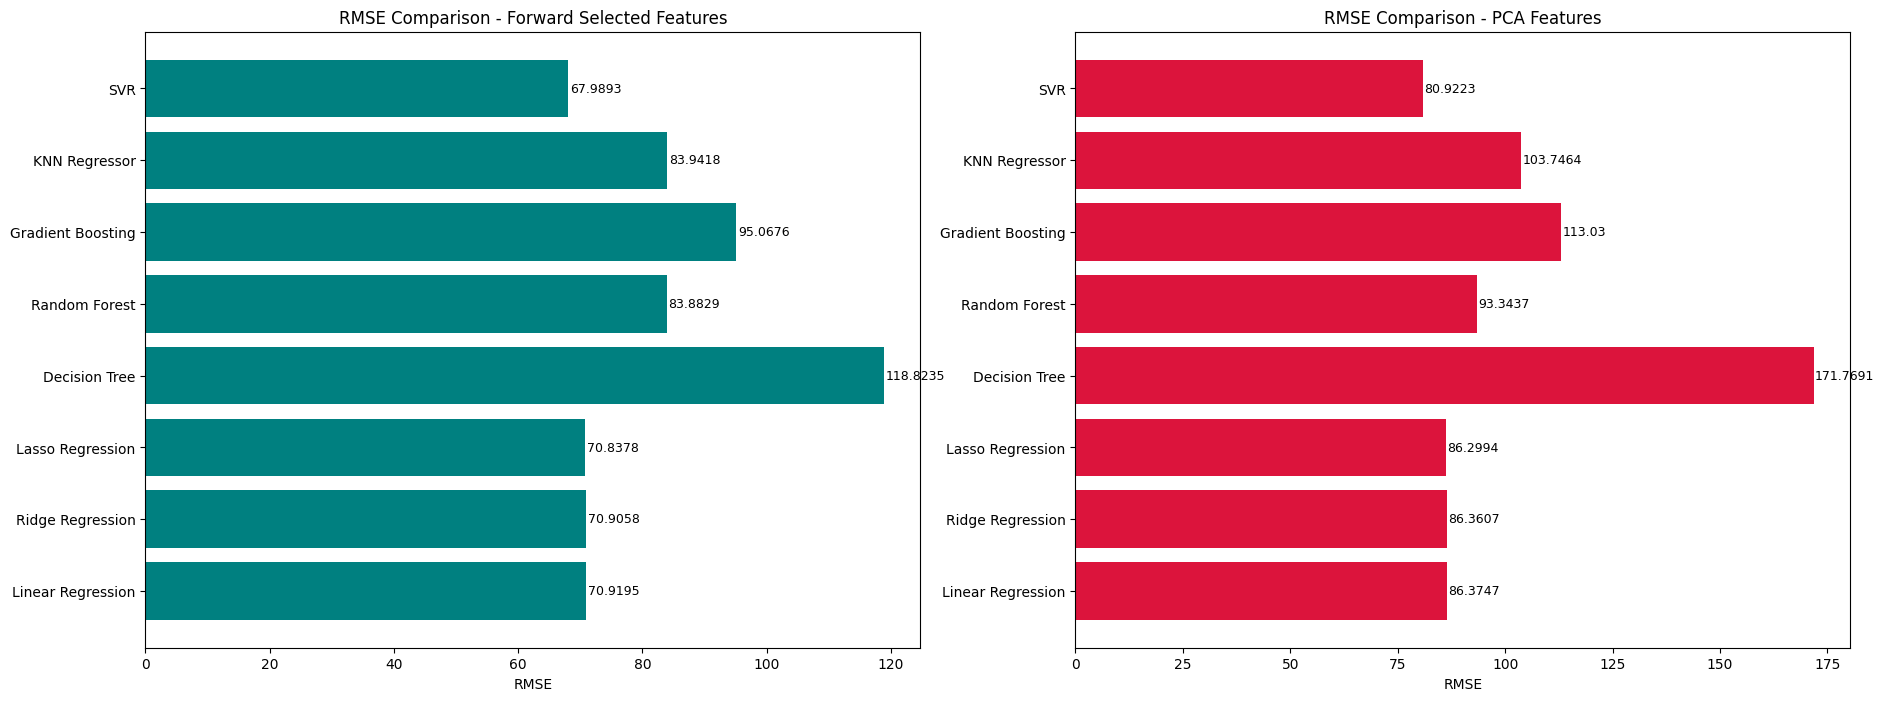

In [22]:
# STEP 9 - plot RMSE comparison
print(" plotting RMSE comparison \n")

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

axes[0].barh(results_df['Model'], results_df['RMSE'], color='teal')
axes[0].set_xlabel("RMSE")
axes[0].set_title("RMSE Comparison - Forward Selected Features")
for i, v in enumerate(results_df['RMSE']):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=9)

axes[1].barh(results_pca_df['Model'], results_pca_df['RMSE'], color='crimson')
axes[1].set_xlabel("RMSE")
axes[1].set_title("RMSE Comparison - PCA Features")
for i, v in enumerate(results_pca_df['RMSE']):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=9)

 plotting actual vs predicted for best model 

actual vs predicted plot saved for SVR


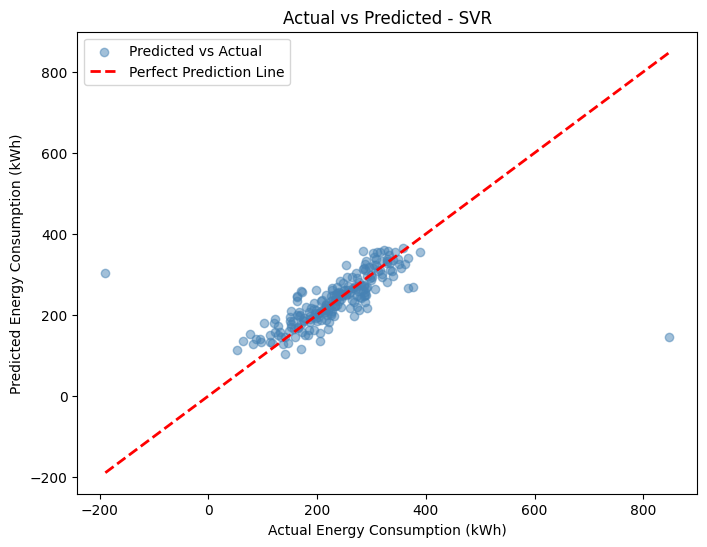

In [24]:
# STEP 10 - plot actual vs predicted for best model
print(" plotting actual vs predicted for best model \n")

# retrain best model on forward features
best_model_name = best_row['Model']
best_model      = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.legend()
print(f"actual vs predicted plot saved for {best_model_name}")

 plotting residuals 


Text(0.5, 1.0, 'Residuals Distribution')

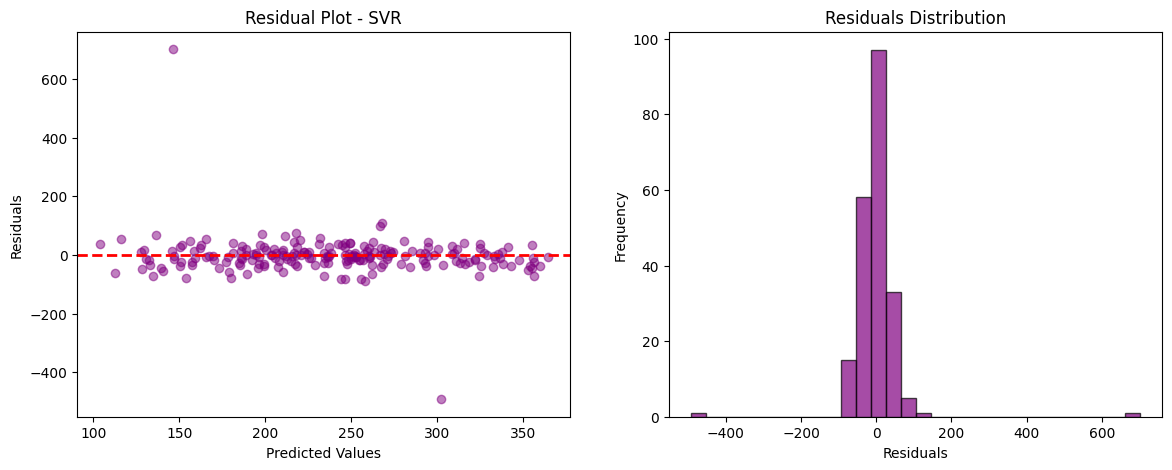

In [25]:
# STEP 11 - plot residuals
print(" plotting residuals ")

residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# residuals scatter
axes[0].scatter(y_pred_best, residuals, alpha=0.5, color='purple')
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title(f"Residual Plot - {best_model_name}")

# residuals distribution
axes[1].hist(residuals, bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Residuals")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residuals Distribution")

	 cross validation box plot 



Text(0.5, 1.0, 'Cross Validation R2 Score Distribution (5-Fold)')

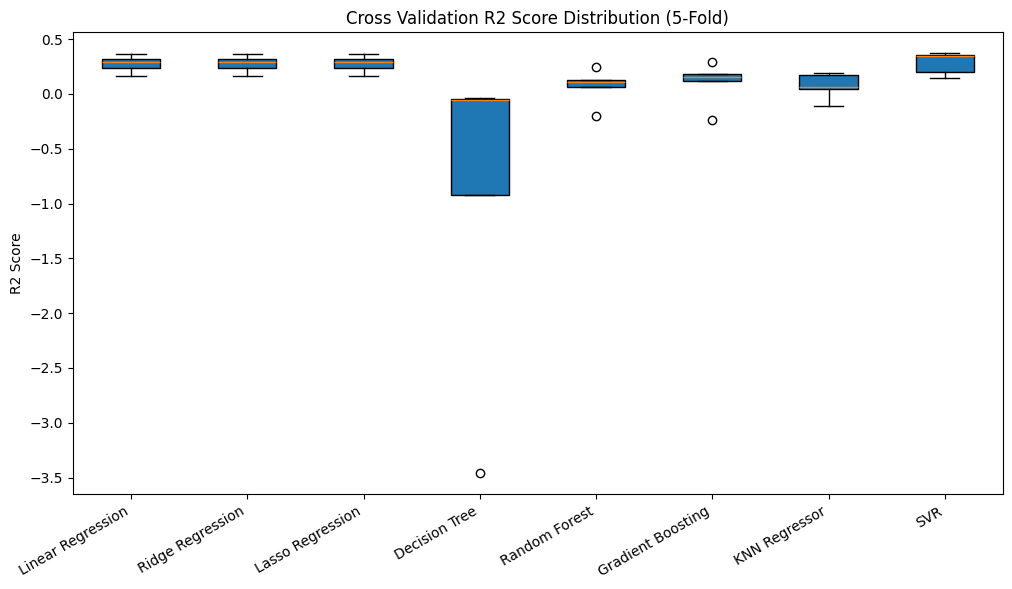

In [26]:
# STEP 12 - cross validation box plot for all models
print("\t cross validation box plot \n")

cv_results = {}
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')
    cv_results[name] = scores

plt.figure(figsize=(12, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)
plt.xticks(rotation=30, ha='right')
plt.ylabel("R2 Score")
plt.title("Cross Validation R2 Score Distribution (5-Fold)")

	 feature importance from Random Forest 
          Feature  Importance
    CO2_Level_ppm    0.297948
    Temperature_C    0.188407
  Appliance_Usage    0.179494
  Occupancy_Level    0.127912
       Event_Type    0.062285
   Wind_Speed_kmh    0.056075
      Time_of_Day    0.045326
Weather_Condition    0.042552


Text(0.5, 1.0, 'Feature Importance - Random Forest')

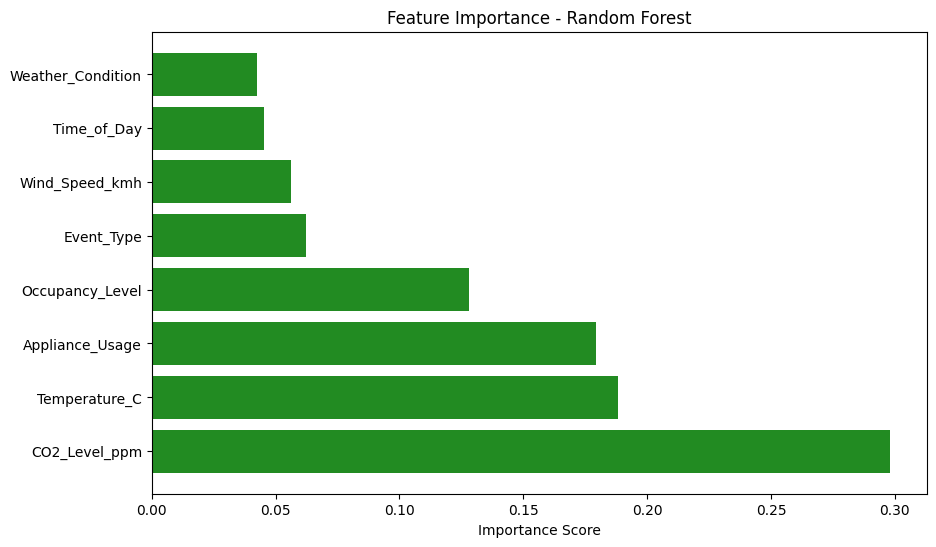

In [27]:
# STEP 13 - feature importance (Random Forest)
print("\t feature importance from Random Forest ")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : importances
}).sort_values('Importance', ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='forestgreen')
plt.xlabel("Importance Score")
plt.title("Feature Importance - Random Forest")

In [33]:
# STEP 14 - final model summary
print("\t\t FINAL MODEL EVALUATION SUMMARY \n")

print("\t\t Forward Selected Features ")
print(results_df[['Model', 'MAE', 'RMSE', 'R2 Score', 'CV R2 Mean']].to_string(index=False))
print()
print("\t\t PCA Features ")
print(results_pca_df[['Model', 'MAE', 'RMSE', 'R2 Score', 'CV R2 Mean']].to_string(index=False))
print()
print(f"BEST MODEL OVERALL  : {best_row['Model']}")
print(f"BEST R2 SCORE       : {best_row['R2 Score']}")
print(f"BEST RMSE           : {best_row['RMSE']}")
print(f"BEST MAE            : {best_row['MAE']}")
print()

		 FINAL MODEL EVALUATION SUMMARY 

		 Forward Selected Features 
            Model     MAE     RMSE  R2 Score  CV R2 Mean
Linear Regression 34.7509  70.9195    0.3152      0.3620
 Ridge Regression 34.7358  70.9058    0.3154      0.3621
 Lasso Regression 34.6628  70.8378    0.3167      0.3622
    Decision Tree 47.5949 118.8235   -0.9225     -1.6510
    Random Forest 38.5511  83.8829    0.0419      0.1393
Gradient Boosting 43.2030  95.0676   -0.2306     -0.0841
    KNN Regressor 42.5740  83.9418    0.0406     -0.0570
              SVR 31.4994  67.9893    0.3706      0.3481

		 PCA Features 
            Model     MAE     RMSE  R2 Score  CV R2 Mean
Linear Regression 50.3534  86.3747   -0.0159      0.1797
 Ridge Regression 50.3427  86.3607   -0.0155      0.1798
 Lasso Regression 50.2920  86.2994   -0.0141      0.1799
    Decision Tree 79.5525 171.7691   -3.0174     -1.8839
    Random Forest 51.3616  93.3437   -0.1864     -0.2295
Gradient Boosting 53.4765 113.0300   -0.7396     -0.3845
    